In [21]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import echopype as ep

In [3]:
path_predict = "/Volumes/sh2506_ext1/leg1_test/prediction"
pred_score_files = sorted(list(Path(path_predict).glob("score_*.zarr")))
pred_softmax_files = sorted(list(Path(path_predict).glob("softmax_*.zarr")))
len(pred_score_files), len(pred_softmax_files)

(56, 56)

## Check prediction score and softmax

In [10]:
da_score = xr.open_zarr(pred_score_files[-2])
da_score

<xarray.Dataset> Size: 2MB
Dimensions:          (depth: 591, ping_time: 480, scatterer_class: 2)
Coordinates:
  * depth            (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time        (ping_time) datetime64[ns] 4kB 2025-06-15T18:20:00 ... 2...
  * scatterer_class  (scatterer_class) <U10 80B 'background' 'hake'
Data variables:
    score            (scatterer_class, depth, ping_time) float32 2MB dask.array<chunksize=(2, 591, 480), meta=np.ndarray>

In [8]:
da_softmax = xr.open_zarr(pred_softmax_files[-2])
da_softmax

<xarray.Dataset> Size: 2MB
Dimensions:          (depth: 591, ping_time: 480, scatterer_class: 2)
Coordinates:
  * depth            (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time        (ping_time) datetime64[ns] 4kB 2025-06-15T18:20:00 ... 2...
  * scatterer_class  (scatterer_class) <U10 80B 'background' 'hake'
Data variables:
    softmax_score    (scatterer_class, depth, ping_time) float32 2MB dask.array<chunksize=(2, 591, 480), meta=np.ndarray>

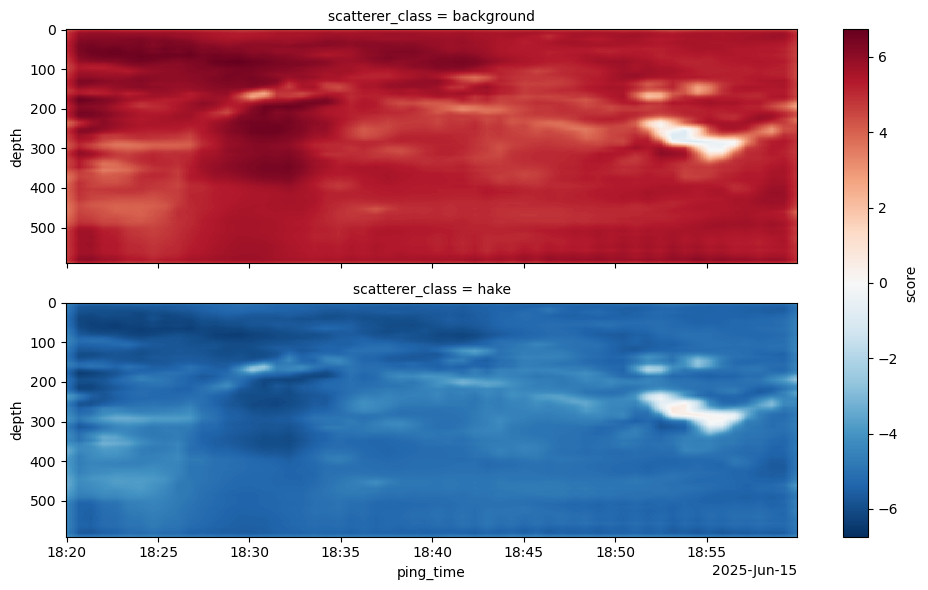

In [11]:
da_score["score"].plot(
    x="ping_time", y="depth",
    row="scatterer_class", col_wrap=1,
    figsize=(10, 6), yincrease=False,
)

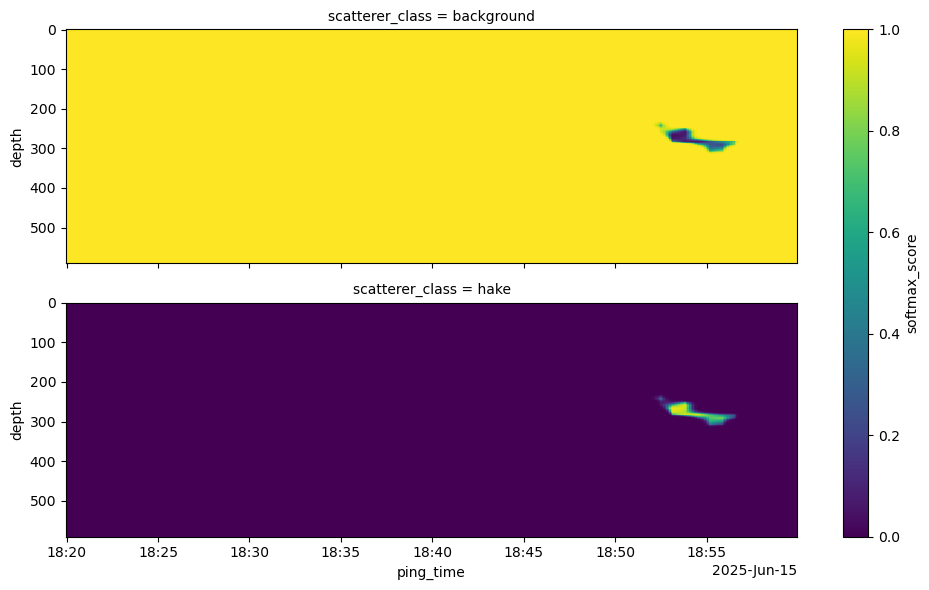

In [12]:
da_softmax["softmax_score"].plot(
    x="ping_time", y="depth",
    row="scatterer_class", col_wrap=1,
    figsize=(10, 6), yincrease=False,
)

In [14]:
start_time, end_time = da_score["ping_time"].min(), da_score["ping_time"].max()
start_time, end_time

(<xarray.DataArray 'ping_time' ()> Size: 8B
 array('2025-06-15T18:20:00.000000000', dtype='datetime64[ns]'),
 <xarray.DataArray 'ping_time' ()> Size: 8B
 array('2025-06-15T18:59:55.000000000', dtype='datetime64[ns]'))

## Check correspondence in MVBS file

In [15]:
path_MVBS = "/Volumes/sh2506_ext1/leg1_test/MVBS"
MVBS_files = sorted(list(Path(path_MVBS).glob("*.zarr")))

In [16]:
MVBS_files[-5:]

[PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250615T180000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250615T182000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250615T184000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250615T190000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250615T192000.zarr')]

In [19]:
# Combine MVBS files into a single dataset
ds_MVBS_combine = xr.open_mfdataset(
    MVBS_files[-5:],
    parallel=True,
    coords="minimal",
    data_vars="minimal",
    compat='override',
    chunks={"channel": -1, "ping_time": -1, "depth": -1},  # load everything into 1 chunk
    engine="zarr",  # use zarr engine for reading
).sel(
    # slice start/end, end exclusive
    ping_time=slice(start_time, end_time-pd.to_timedelta("10milliseconds")),
    depth=slice(None, 590)  # slice to what the model expects
)

In [22]:
ds_MVBS_combine = ep.consolidate.swap_dims_channel_frequency(ds_MVBS_combine)

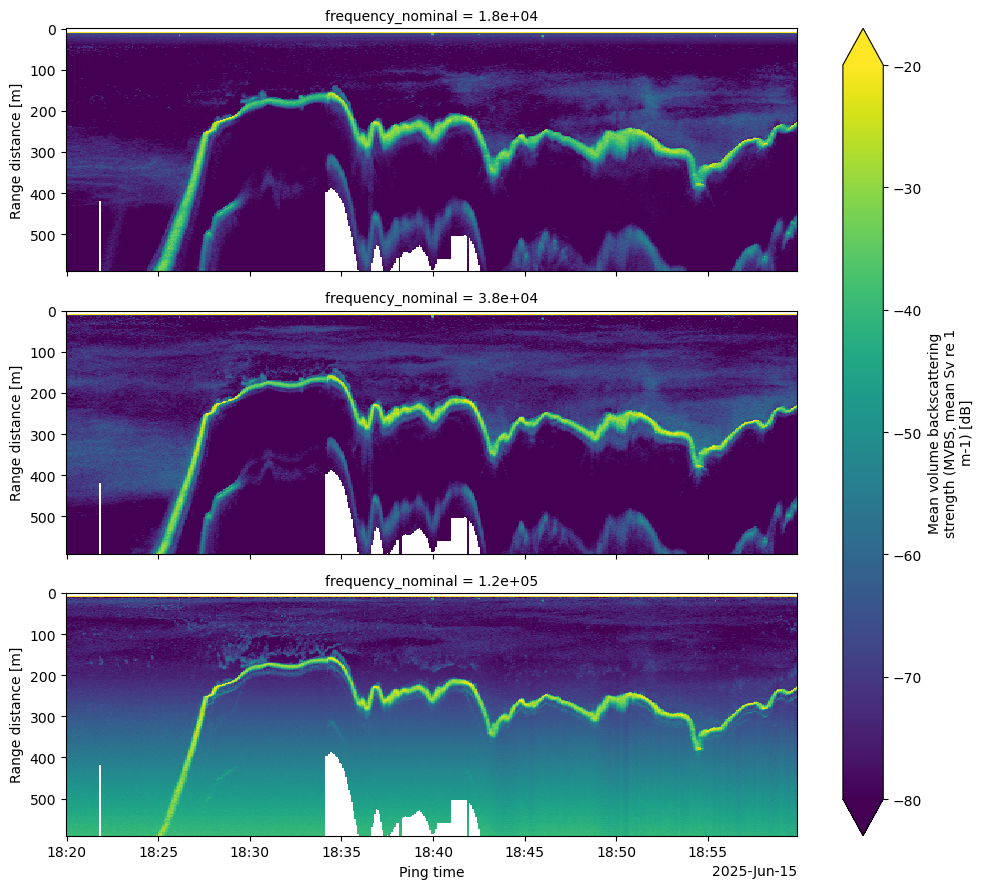

In [27]:
ds_MVBS_combine["Sv"].sel(depth=slice(None, 590), frequency_nominal=[18000, 38000, 120000]).plot(
    x="ping_time", y="depth",
    row="frequency_nominal", col_wrap=1,
    figsize=(10, 9),
    cmap="viridis", vmin=-80, vmax=-20, yincrease=False,
)

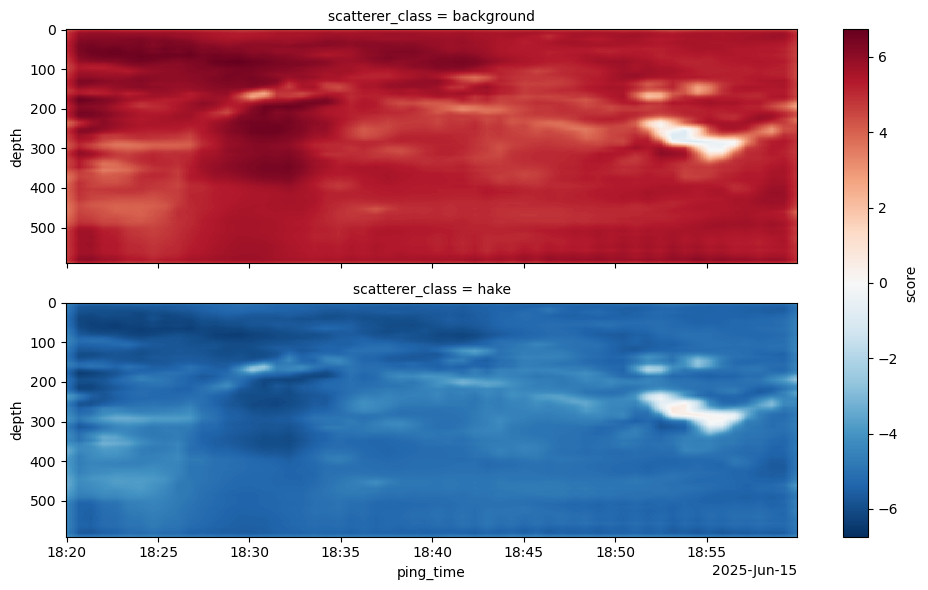

In [24]:
da_score["score"].plot(
    x="ping_time", y="depth",
    row="scatterer_class", col_wrap=1,
    figsize=(10, 6), yincrease=False,
)